# Entrega sprint semana 6
## Experimentos A/B para deteccion de valores unitarios atipicos

**Objetivo:** comparar un baseline contra 2 variantes y adoptar la alternativa tecnicamente viable.  
**Metrica central:** F1-score para la clase outlier.  
**Metricas secundarias:** precision, recall, PR-AUC, registros detectados, tasa de deteccion y latencia.

In [5]:
# =============================================================================
# 1. CONFIGURACION GENERAL
# =============================================================================

import hashlib
import logging
import time
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, precision_score, recall_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from sqlalchemy import create_engine, text
from sqlalchemy.pool import NullPool

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

SERVIDOR = r"DESKTOP-OGU19A7\SQLEXPRESS,56878"
BASE_DATOS = "DB_GEE_DW_ADUANAS"
ESQUEMA = "SC_ADUANA"
PROCEDIMIENTO = "SP_VALORES_UNITARIOS"
DRIVER = "ODBC+Driver+17+for+SQL+Server"
FEC_INI = "2024-01-01"
FEC_FIN = "2024-12-31"

COL_GRUPO = "NUM_SPN_R"
COL_ADUANA = "ADUANA"
COL_FOB = "FOB_DOLAR"
COL_VU_ORIGEN = "MTO_VALOR_UNTARIO_V"
COL_FECHA_CANDIDATAS = ["FEC_NUM", "FECHA", "FEC_DECLARACION", "FECHA_DECLARACION"]

TEST_SIZE = 0.30
UMBRAL_Z_ROBUSTO_GT = 3.5
MIN_REGISTROS_GRUPO = 20

OUTPUT_DIR = Path("outputs_semana6")
LOGS_DIR = OUTPUT_DIR / "logs"
FIG_DIR = OUTPUT_DIR / "figuras"
DATA_DIR = OUTPUT_DIR / "datos"
for carpeta in [OUTPUT_DIR, LOGS_DIR, FIG_DIR, DATA_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)

LOG_CSV = LOGS_DIR / "metrics_experimentos_semana6.csv"
README_PATH = OUTPUT_DIR / "README_REPRODUCIBILIDAD.txt"
SNAPSHOT_PATH = DATA_DIR / "snapshot_semana6.csv"

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
log = logging.getLogger("semana6")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

print("CONFIGURACION LISTA")
print(f"Periodo: {FEC_INI} a {FEC_FIN}")
print(f"Seed: {SEED}")
print(f"Salida: {OUTPUT_DIR.resolve()}")

CONFIGURACION LISTA
Periodo: 2024-01-01 a 2024-12-31
Seed: 42
Salida: C:\Users\hp\Downloads\ROBOTICA\TESIS_2\notebooks\03_sprint2_complemento\outputs_semana6


In [6]:
# =============================================================================
# 2. FUNCIONES BASE
# =============================================================================

def crear_motor_sql_server() -> object:
    """
    Crea el motor de conexion hacia SQL Server usando autenticacion integrada.

    Returns
    -------
    object
        Motor SQLAlchemy configurado con NullPool.
    """
    url = f"mssql+pyodbc://{SERVIDOR}/{BASE_DATOS}?driver={DRIVER}&Trusted_Connection=yes"
    return create_engine(url, echo=False, poolclass=NullPool)


def cargar_datos_sql_server() -> pd.DataFrame:
    """
    Ejecuta el procedimiento almacenado y devuelve el dataset base.

    Returns
    -------
    pd.DataFrame
        Datos extraidos desde SQL Server.
    """
    motor = crear_motor_sql_server()
    sentencia = text(
        f"EXEC [{BASE_DATOS}].[{ESQUEMA}].[{PROCEDIMIENTO}] "
        f"@ACCION='EDA_BASE', @FEC_INI='{FEC_INI}', @FEC_FIN='{FEC_FIN}'"
    )
    with motor.connect() as conn:
        resultado = conn.execute(sentencia)
        df = pd.DataFrame.from_records(resultado.fetchall(), columns=list(resultado.keys()))
    if df.empty:
        raise RuntimeError("El procedimiento retorno 0 filas.")
    return df


def preparar_dataset(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia columnas numericas, elimina registros no validos y crea variables base.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Dataset original extraido desde SQL Server.

    Returns
    -------
    pd.DataFrame
        Dataset listo para experimentos A/B.
    """
    columnas_requeridas = [COL_GRUPO, COL_ADUANA, COL_FOB, COL_VU_ORIGEN]
    faltantes = [col for col in columnas_requeridas if col not in df_raw.columns]
    if faltantes:
        raise ValueError(f"Columnas faltantes: {faltantes}")

    columnas_base = columnas_requeridas.copy()
    for col_fecha in COL_FECHA_CANDIDATAS:
        if col_fecha in df_raw.columns:
            columnas_base.append(col_fecha)
            break

    df = df_raw[columnas_base].copy()
    df[COL_GRUPO] = df[COL_GRUPO].astype(str).str.strip()
    df[COL_ADUANA] = df[COL_ADUANA].astype(str).str.strip().str.upper()
    df["VU"] = pd.to_numeric(df[COL_VU_ORIGEN], errors="coerce")
    df[COL_FOB] = pd.to_numeric(df[COL_FOB], errors="coerce")
    df = df.dropna(subset=[COL_GRUPO, COL_ADUANA, COL_FOB, "VU"])
    df = df[(df[COL_FOB] > 0) & (df["VU"] > 0)].copy()

    conteo_grupo = df[COL_GRUPO].value_counts()
    grupos_validos = conteo_grupo[conteo_grupo >= MIN_REGISTROS_GRUPO].index
    df = df[df[COL_GRUPO].isin(grupos_validos)].copy()
    if df.empty:
        raise ValueError("El dataset quedo vacio despues de la limpieza.")

    df["LOG_VU"] = np.log1p(df["VU"])
    df["LOG_FOB"] = np.log1p(df[COL_FOB])
    return df.reset_index(drop=True)


def crear_etiqueta_proxy(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea una etiqueta proxy de outlier con z-score robusto por subpartida.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio.

    Returns
    -------
    pd.DataFrame
        Dataset con columna y_true.
    """
    salida = df.copy()
    mediana = salida.groupby(COL_GRUPO)["LOG_VU"].transform("median")
    mad = salida.groupby(COL_GRUPO)["LOG_VU"].transform(lambda s: np.median(np.abs(s - np.median(s))))
    salida["Z_ROBUSTO"] = 0.6745 * (salida["LOG_VU"] - mediana) / (mad + 1e-9)
    salida["y_true"] = (salida["Z_ROBUSTO"].abs() >= UMBRAL_Z_ROBUSTO_GT).astype(int)
    return salida


def calcular_hash_archivo(ruta: Path) -> str:
    """
    Calcula el hash SHA256 de un archivo.

    Parameters
    ----------
    ruta : Path
        Ruta del archivo.

    Returns
    -------
    str
        Hash SHA256 en hexadecimal.
    """
    sha = hashlib.sha256()
    with ruta.open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            sha.update(bloque)
    return sha.hexdigest()

In [7]:
# =============================================================================
# 3. CARGA Y RESUMEN DEL DATASET
# =============================================================================

df_raw = cargar_datos_sql_server()
df_eval = preparar_dataset(df_raw)
df_eval = crear_etiqueta_proxy(df_eval)

SNAPSHOT_COLS = [COL_GRUPO, COL_ADUANA, COL_FOB, "VU", "LOG_VU", "LOG_FOB", "Z_ROBUSTO", "y_true"]
df_eval[SNAPSHOT_COLS].to_csv(SNAPSHOT_PATH, index=False, sep="|", encoding="utf-8")
HASH_SNAPSHOT = calcular_hash_archivo(SNAPSHOT_PATH)

resumen_dataset = pd.DataFrame({
    "indicador": ["registros_limpios", "subpartidas", "aduanas", "outliers_proxy", "tasa_outlier_proxy", "hash_snapshot_sha256"],
    "valor": [
        f"{len(df_eval):,}",
        f"{df_eval[COL_GRUPO].nunique():,}",
        f"{df_eval[COL_ADUANA].nunique():,}",
        f"{int(df_eval['y_true'].sum()):,}",
        f"{df_eval['y_true'].mean():.4f}",
        HASH_SNAPSHOT,
    ],
})

resumen_dataset

,indicador,valor
0,registros_limpios,"388,440"
1,subpartidas,444
2,aduanas,16
3,outliers_proxy,"20,016"
4,tasa_outlier_proxy,0.0515
5,hash_snapshot_sha256,bd70c05d1c0f5e10f3628e56fa6f31bf6042f3b7f77496...


In [8]:
# =============================================================================
# 4. SPLIT SIN LEAKAGE DENTRO DE CADA SUBPARTIDA
# =============================================================================

from sklearn.model_selection import train_test_split

def crear_split_por_cada_subpartida(df_eval: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    """
    Crea train/test dentro de cada subpartida.

    Cada subpartida se trata como un universo independiente. Por ello, el split
    no separa subpartidas completas, sino que divide los registros dentro de cada
    NUM_SPN_R para que cada producto tenga representacion en train y test.

    Parameters
    ----------
    df_eval : pd.DataFrame
        Dataset limpio con variables de evaluacion y columna y_true.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame, str]
        DataFrame de entrenamiento, DataFrame de prueba y descripcion del split.

    Raises
    ------
    ValueError
        Si faltan columnas necesarias o no hay datos suficientes.
    """
    columnas_requeridas = [
        COL_GRUPO,
        "VU",
        "LOG_VU",
        "LOG_FOB",
        "y_true"
    ]

    faltantes = [
        columna for columna in columnas_requeridas
        if columna not in df_eval.columns
    ]

    if faltantes:
        raise ValueError(f"Columnas faltantes para el split: {faltantes}")

    lista_train = []
    lista_test = []
    subpartidas_omitidas = []

    for subpartida, df_subpartida in df_eval.groupby(COL_GRUPO):
        df_subpartida = df_subpartida.copy()

        if len(df_subpartida) < 5:
            subpartidas_omitidas.append(subpartida)
            continue

        tiene_dos_clases = df_subpartida["y_true"].nunique() >= 2
        clase_minima = df_subpartida["y_true"].value_counts().min()

        if tiene_dos_clases and clase_minima >= 2:
            train_sub, test_sub = train_test_split(
                df_subpartida,
                test_size=TEST_SIZE,
                random_state=SEED,
                stratify=df_subpartida["y_true"]
            )
        else:
            train_sub, test_sub = train_test_split(
                df_subpartida,
                test_size=TEST_SIZE,
                random_state=SEED,
                shuffle=True
            )

        lista_train.append(train_sub)
        lista_test.append(test_sub)

    if not lista_train or not lista_test:
        raise ValueError("No se pudo crear split. No hay subpartidas con registros suficientes.")

    train_df = pd.concat(lista_train, ignore_index=True)
    test_df = pd.concat(lista_test, ignore_index=True)

    descripcion_split = (
        f"Split {int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)} "
        f"dentro de cada {COL_GRUPO}"
    )

    print("Subpartidas omitidas por pocos registros:", len(subpartidas_omitidas))

    return train_df, test_df, descripcion_split


train_df, test_df, TIPO_SPLIT = crear_split_por_cada_subpartida(df_eval)

print("Split definido")
print("=" * 80)
print(f"Metodo              : {TIPO_SPLIT}")
print(f"Train               : {len(train_df):,} registros")
print(f"Test                : {len(test_df):,} registros")
print(f"Subpartidas train   : {train_df[COL_GRUPO].nunique():,}")
print(f"Subpartidas test    : {test_df[COL_GRUPO].nunique():,}")
print(f"Outliers train      : {train_df['y_true'].sum():,} ({100 * train_df['y_true'].mean():.2f}%)")
print(f"Outliers test       : {test_df['y_true'].sum():,} ({100 * test_df['y_true'].mean():.2f}%)")

# =============================================================================
# 4.1 VALIDACION DEL SPLIT POR SUBPARTIDA
# =============================================================================

subpartidas_train = set(train_df[COL_GRUPO].astype(str).unique())
subpartidas_test = set(test_df[COL_GRUPO].astype(str).unique())

subpartidas_comunes = subpartidas_train.intersection(subpartidas_test)

print("Validacion del split")
print("=" * 80)
print(f"Subpartidas en train        : {len(subpartidas_train):,}")
print(f"Subpartidas en test         : {len(subpartidas_test):,}")
print(f"Subpartidas en ambos grupos : {len(subpartidas_comunes):,}")

if len(subpartidas_comunes) > 0:
    print("OK: cada subpartida tiene datos separados en train y test.")
else:
    print("ALERTA: no hay subpartidas comunes entre train y test.")

Subpartidas omitidas por pocos registros: 0
Split definido
Metodo              : Split 70/30 dentro de cada NUM_SPN_R
Train               : 271,711 registros
Test                : 116,729 registros
Subpartidas train   : 444
Subpartidas test    : 444
Outliers train      : 13,976 (5.14%)
Outliers test       : 6,040 (5.17%)
Validacion del split
Subpartidas en train        : 444
Subpartidas en test         : 444
Subpartidas en ambos grupos : 444
OK: cada subpartida tiene datos separados en train y test.


In [9]:
# =============================================================================
# 5. EXPERIMENTOS A/B
# =============================================================================

def ajustar_iqr_por_grupo(train: pd.DataFrame, valor_col: str) -> tuple[pd.DataFrame, tuple[float, float]]:
    """
    Ajusta limites IQR por grupo usando solo train.

    Parameters
    ----------
    train : pd.DataFrame
        Datos de entrenamiento.
    valor_col : str
        Columna numerica usada para calcular IQR.

    Returns
    -------
    tuple[pd.DataFrame, tuple[float, float]]
        Tabla de limites por grupo y limites globales de respaldo.
    """
    limites = train.groupby(COL_GRUPO)[valor_col].quantile([0.25, 0.75]).unstack()
    limites.columns = ["q1", "q3"]
    limites["iqr"] = limites["q3"] - limites["q1"]
    limites["lim_inf"] = limites["q1"] - 1.5 * limites["iqr"]
    limites["lim_sup"] = limites["q3"] + 1.5 * limites["iqr"]
    limites = limites.reset_index()[[COL_GRUPO, "lim_inf", "lim_sup"]]
    q1_global = train[valor_col].quantile(0.25)
    q3_global = train[valor_col].quantile(0.75)
    iqr_global = q3_global - q1_global
    return limites, (q1_global - 1.5 * iqr_global, q3_global + 1.5 * iqr_global)


def predecir_iqr(test: pd.DataFrame, valor_col: str, limites: pd.DataFrame, globales: tuple[float, float]) -> np.ndarray:
    """
    Predice outliers aplicando limites IQR ajustados en train.

    Parameters
    ----------
    test : pd.DataFrame
        Datos de evaluacion.
    valor_col : str
        Columna numerica evaluada.
    limites : pd.DataFrame
        Limites IQR por grupo.
    globales : tuple[float, float]
        Limite inferior y superior global para grupos no vistos.

    Returns
    -------
    np.ndarray
        Vector binario de prediccion.
    """
    eval_df = test[[COL_GRUPO, valor_col]].merge(limites, on=COL_GRUPO, how="left")
    eval_df["lim_inf"] = eval_df["lim_inf"].fillna(globales[0])
    eval_df["lim_sup"] = eval_df["lim_sup"].fillna(globales[1])
    return ((eval_df[valor_col] < eval_df["lim_inf"]) | (eval_df[valor_col] > eval_df["lim_sup"])).astype(int).to_numpy()


def ajustar_winsor_por_grupo(train: pd.DataFrame) -> pd.DataFrame:
    """
    Ajusta percentiles P5 y P95 por grupo usando solo train.

    Parameters
    ----------
    train : pd.DataFrame
        Datos de entrenamiento.

    Returns
    -------
    pd.DataFrame
        Tabla de limites de winsorizacion por grupo.
    """
    limites = train.groupby(COL_GRUPO)["VU"].quantile([0.05, 0.95]).unstack()
    limites.columns = ["p5", "p95"]
    return limites.reset_index()


def aplicar_winsor(df: pd.DataFrame, limites: pd.DataFrame, p5_global: float, p95_global: float) -> pd.Series:
    """
    Aplica winsorizacion con parametros ajustados en train.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset a transformar.
    limites : pd.DataFrame
        P5 y P95 por grupo.
    p5_global : float
        P5 global de respaldo.
    p95_global : float
        P95 global de respaldo.

    Returns
    -------
    pd.Series
        Serie winsorizada.
    """
    base = df[[COL_GRUPO, "VU"]].merge(limites, on=COL_GRUPO, how="left")
    base["p5"] = base["p5"].fillna(p5_global)
    base["p95"] = base["p95"].fillna(p95_global)
    return base["VU"].clip(lower=base["p5"], upper=base["p95"])


def evaluar_modelo(nombre: str, variante: str, y_true: np.ndarray, y_pred: np.ndarray, latencia_ms: float) -> dict:
    """
    Calcula metricas comparables para una variante.

    Parameters
    ----------
    nombre : str
        Nombre del modelo.
    variante : str
        Codigo de variante.
    y_true : np.ndarray
        Etiqueta proxy.
    y_pred : np.ndarray
        Prediccion binaria.
    latencia_ms : float
        Tiempo de ejecucion en milisegundos.

    Returns
    -------
    dict
        Diccionario con metricas principales y secundarias.
    """
    return {
        "variante": variante,
        "modelo": nombre,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_pred),
        "detectados": int(np.sum(y_pred)),
        "tasa_detectada": float(np.mean(y_pred)),
        "latencia_ms": float(latencia_ms),
    }

y_true = test_df["y_true"].to_numpy()
resultados = []
predicciones = {}

inicio = time.perf_counter()
limites_a, globales_a = ajustar_iqr_por_grupo(train_df, "VU")
pred_a = predecir_iqr(test_df, "VU", limites_a, globales_a)
resultados.append(evaluar_modelo("IQR sobre VU original", "A_BASELINE", y_true, pred_a, (time.perf_counter() - inicio) * 1000))
predicciones["A_BASELINE"] = pred_a

inicio = time.perf_counter()
limites_b, globales_b = ajustar_iqr_por_grupo(train_df, "LOG_VU")
pred_b = predecir_iqr(test_df, "LOG_VU", limites_b, globales_b)
resultados.append(evaluar_modelo("IQR sobre log1p(VU)", "B_LOG", y_true, pred_b, (time.perf_counter() - inicio) * 1000))
predicciones["B_LOG"] = pred_b

inicio = time.perf_counter()
limites_w = ajustar_winsor_por_grupo(train_df)
p5_global = train_df["VU"].quantile(0.05)
p95_global = train_df["VU"].quantile(0.95)
train_w = train_df.copy()
test_w = test_df.copy()
train_w["VU_WINS"] = aplicar_winsor(train_w, limites_w, p5_global, p95_global)
test_w["VU_WINS"] = aplicar_winsor(test_w, limites_w, p5_global, p95_global)
limites_c, globales_c = ajustar_iqr_por_grupo(train_w, "VU_WINS")
pred_c = predecir_iqr(test_w, "VU_WINS", limites_c, globales_c)
resultados.append(evaluar_modelo("IQR sobre VU winsorizado P5-P95", "C_WINS", y_true, pred_c, (time.perf_counter() - inicio) * 1000))
predicciones["C_WINS"] = pred_c

tabla_resultados = pd.DataFrame(resultados)
baseline_f1 = tabla_resultados.loc[tabla_resultados["variante"] == "A_BASELINE", "f1"].iloc[0]
tabla_resultados["mejora_vs_baseline"] = tabla_resultados["f1"] - baseline_f1
tabla_resultados = tabla_resultados.sort_values(["f1", "pr_auc", "latencia_ms"], ascending=[False, False, True]).reset_index(drop=True)

tabla_resultados_round = tabla_resultados.copy()
for col in ["f1", "precision", "recall", "pr_auc", "tasa_detectada", "latencia_ms", "mejora_vs_baseline"]:
    tabla_resultados_round[col] = tabla_resultados_round[col].round(4)

tabla_resultados_round

,variante,modelo,f1,precision,recall,pr_auc,detectados,tasa_detectada,latencia_ms,mejora_vs_baseline
0,B_LOG,IQR sobre log1p(VU),0.7327,0.7121,0.7545,0.5500,6399,0.0548,137.5275,0.0788
1,A_BASELINE,IQR sobre VU original,0.6539,0.6115,0.7026,0.4451,6940,0.0595,154.9654,0.0000
2,C_WINS,IQR sobre VU winsorizado P5-P95,0.5802,0.6636,0.5154,0.3671,4691,0.0402,466.9867,-0.0737


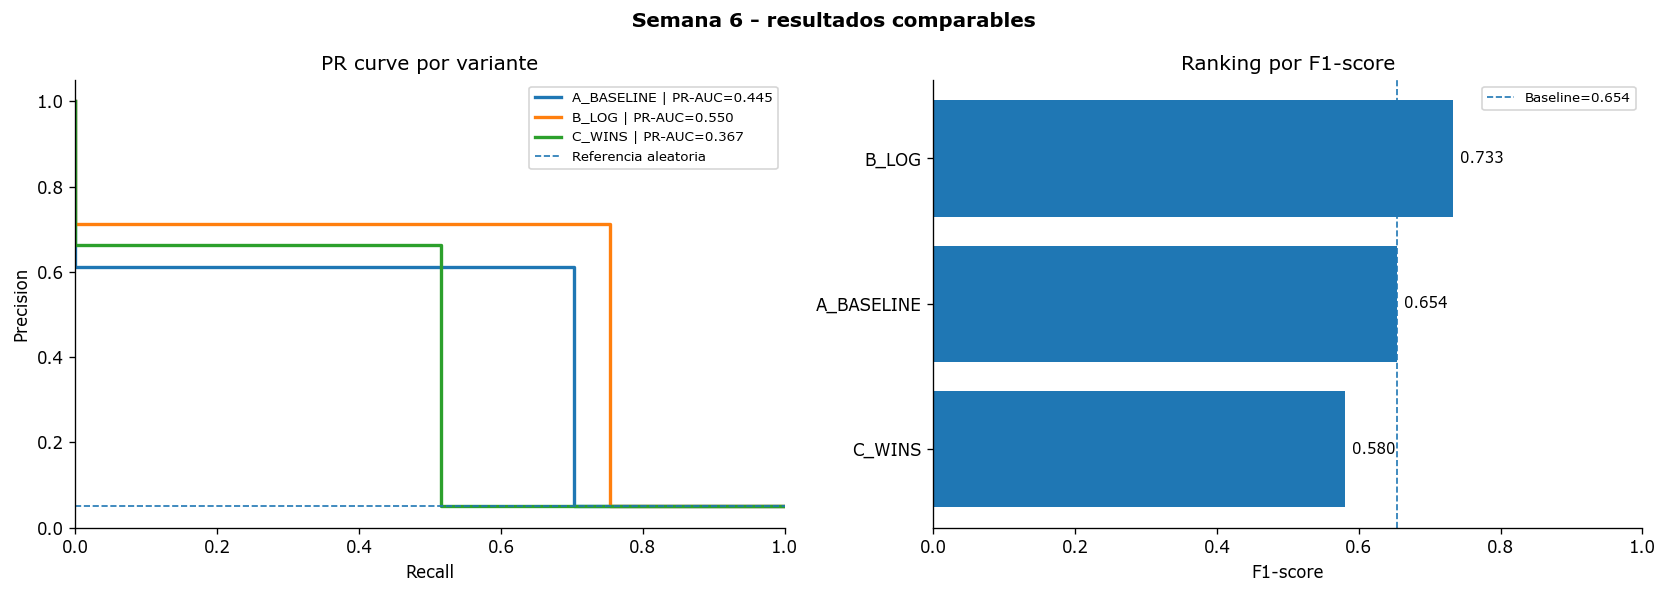

Figura guardada: outputs_semana6\figuras\semana6_pr_curve_ranking.png


In [10]:
# =============================================================================
# 6. GRAFICO UNICO DE RESULTADOS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for variante, pred in predicciones.items():
    precision, recall, _ = precision_recall_curve(y_true, pred)
    pr_auc = average_precision_score(y_true, pred)
    axes[0].step(recall, precision, where="post", linewidth=2, label=f"{variante} | PR-AUC={pr_auc:.3f}")

axes[0].axhline(y_true.mean(), linestyle="--", linewidth=1, label="Referencia aleatoria")
axes[0].set_title("PR curve por variante")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)

ranking = tabla_resultados.sort_values("f1", ascending=True)
axes[1].barh(ranking["variante"], ranking["f1"])
for i, valor in enumerate(ranking["f1"]):
    axes[1].text(valor + 0.01, i, f"{valor:.3f}", va="center", fontsize=9)
axes[1].axvline(baseline_f1, linestyle="--", linewidth=1, label=f"Baseline={baseline_f1:.3f}")
axes[1].set_title("Ranking por F1-score")
axes[1].set_xlabel("F1-score")
axes[1].set_xlim(0, max(1.0, ranking["f1"].max() + 0.15))
axes[1].legend(fontsize=8)

plt.suptitle("Semana 6 - resultados comparables", fontweight="bold")
plt.tight_layout()
FIG_PATH = FIG_DIR / "semana6_pr_curve_ranking.png"
plt.savefig(FIG_PATH, dpi=120, bbox_inches="tight")
plt.show()

print(f"Figura guardada: {FIG_PATH}")

In [11]:
# =============================================================================
# 7. CONCLUSION, DECISION Y REPRODUCIBILIDAD
# =============================================================================

mejor = tabla_resultados.iloc[0]

tabla_export = tabla_resultados_round.copy()
tabla_export.insert(0, "fecha_ejecucion", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
tabla_export.insert(1, "seed", SEED)
tabla_export.insert(2, "split", TIPO_SPLIT)
tabla_export.insert(3, "periodo", f"{FEC_INI} a {FEC_FIN}")
tabla_export.insert(4, "hash_snapshot_sha256", HASH_SNAPSHOT)
tabla_export.to_csv(LOG_CSV, index=False, sep="|", encoding="utf-8")

readme = f"""
ENTREGA SPRINT SEMANA 6 - REPRODUCIBILIDAD

Comando sugerido:
    jupyter notebook sprint_semana6_resumido_autonomo.ipynb

Parametros:
    seed={SEED}
    periodo={FEC_INI} a {FEC_FIN}
    split={TIPO_SPLIT}
    metrica_principal=F1-score
    metricas_secundarias=precision, recall, PR-AUC, detectados, tasa_detectada, latencia_ms

Archivos generados:
    metricas={LOG_CSV}
    snapshot={SNAPSHOT_PATH}
    figura={FIG_PATH}

Hash snapshot SHA256:
    {HASH_SNAPSHOT}

Decision tecnica:
    adoptar={mejor['variante']} - {mejor['modelo']}
    f1={mejor['f1']:.4f}
    precision={mejor['precision']:.4f}
    recall={mejor['recall']:.4f}
    pr_auc={mejor['pr_auc']:.4f}
    latencia_ms={mejor['latencia_ms']:.4f}

Riesgos y siguientes pasos:
    1. La etiqueta y_true es proxy estadistica; requiere validacion experta para reducir falsos positivos.
    2. Monitorear drift por subpartida y aduana antes de pasar a un flujo productivo.
    3. Siguiente sprint: calibrar umbrales por familia de producto y revisar errores por variable.
""".strip()
README_PATH.write_text(readme, encoding="utf-8")

print("CONCLUSION Y DECISION")
print("=" * 80)
print(f"Variante adoptada : {mejor['variante']} - {mejor['modelo']}")
print(f"F1                : {mejor['f1']:.4f}")
print(f"Precision         : {mejor['precision']:.4f}")
print(f"Recall            : {mejor['recall']:.4f}")
print(f"PR-AUC            : {mejor['pr_auc']:.4f}")
print(f"Latencia ms       : {mejor['latencia_ms']:.4f}")
print()
print("Reproducibilidad")
print(f"Metricas : {LOG_CSV}")
print(f"Snapshot : {SNAPSHOT_PATH}")
print(f"README   : {README_PATH}")
print(f"Hash     : {HASH_SNAPSHOT}")

CONCLUSION Y DECISION
Variante adoptada : B_LOG - IQR sobre log1p(VU)
F1                : 0.7327
Precision         : 0.7121
Recall            : 0.7545
PR-AUC            : 0.5500
Latencia ms       : 137.5275

Reproducibilidad
Metricas : outputs_semana6\logs\metrics_experimentos_semana6.csv
Snapshot : outputs_semana6\datos\snapshot_semana6.csv
README   : outputs_semana6\README_REPRODUCIBILIDAD.txt
Hash     : bd70c05d1c0f5e10f3628e56fa6f31bf6042f3b7f774966ed8814b776517c97f


In [14]:
# =============================================================================
# 9. VALIDACION ADICIONAL: CROSS-VALIDATION POR SUBPARTIDA
# =============================================================================

from sklearn.model_selection import KFold, StratifiedKFold

N_FOLDS_CV = 5
MIN_REGISTROS_CV = 20

def crear_folds_cv_por_subpartida(df_eval: pd.DataFrame) -> list[tuple[pd.DataFrame, pd.DataFrame, int, str]]:
    """
    Crea folds de cross-validation dentro de cada subpartida.

    Cada subpartida se considera un universo independiente. Por ello, no se
    valida una subpartida contra otra, sino que dentro de cada NUM_SPN_R se
    crean particiones de entrenamiento y prueba.

    Parameters
    ----------
    df_eval : pd.DataFrame
        Dataset preparado con variables de evaluacion y columna y_true.

    Returns
    -------
    list[tuple[pd.DataFrame, pd.DataFrame, int, str]]
        Lista de folds con train, test, numero de fold y subpartida.

    Raises
    ------
    ValueError
        Si faltan columnas necesarias o no existen subpartidas suficientes.
    """
    columnas_requeridas = [
        COL_GRUPO,
        "VU",
        "LOG_VU",
        "y_true"
    ]

    faltantes = [
        columna for columna in columnas_requeridas
        if columna not in df_eval.columns
    ]

    if faltantes:
        raise ValueError(f"Columnas faltantes para cross-validation: {faltantes}")

    folds_cv = []
    subpartidas_omitidas = []

    for subpartida, df_sub in df_eval.groupby(COL_GRUPO):
        df_sub = df_sub.copy().reset_index(drop=True)

        if len(df_sub) < MIN_REGISTROS_CV:
            subpartidas_omitidas.append(subpartida)
            continue

        n_folds_sub = min(
            N_FOLDS_CV,
            len(df_sub)
        )

        tiene_dos_clases = df_sub["y_true"].nunique() >= 2
        clase_minima = df_sub["y_true"].value_counts().min()

        if tiene_dos_clases and clase_minima >= n_folds_sub:
            splitter = StratifiedKFold(
                n_splits=n_folds_sub,
                shuffle=True,
                random_state=SEED
            )

            splits = splitter.split(
                df_sub,
                df_sub["y_true"]
            )
        else:
            splitter = KFold(
                n_splits=n_folds_sub,
                shuffle=True,
                random_state=SEED
            )

            splits = splitter.split(df_sub)

        for fold_id, (idx_train, idx_test) in enumerate(splits, start=1):
            train_sub = df_sub.iloc[idx_train].copy()
            test_sub = df_sub.iloc[idx_test].copy()

            folds_cv.append(
                (
                    train_sub,
                    test_sub,
                    fold_id,
                    str(subpartida)
                )
            )

    if not folds_cv:
        raise ValueError("No se pudo crear cross-validation por subpartida.")

    print("Cross-validation por subpartida definido")
    print("=" * 80)
    print(f"Subpartidas totales      : {df_eval[COL_GRUPO].nunique():,}")
    print(f"Subpartidas evaluadas    : {df_eval[COL_GRUPO].nunique() - len(subpartidas_omitidas):,}")
    print(f"Subpartidas omitidas     : {len(subpartidas_omitidas):,}")
    print(f"Folds maximos por grupo  : {N_FOLDS_CV}")
    print(f"Total folds generados    : {len(folds_cv):,}")

    return folds_cv


folds_cv = crear_folds_cv_por_subpartida(df_eval)


# =============================================================================
# 9.1 EJECUCION DE EXPERIMENTOS CON CROSS-VALIDATION
# =============================================================================

resultados_cv = []

for fold_global, (train_cv, test_cv, fold_subpartida, subpartida) in enumerate(folds_cv, start=1):
    y_true_cv = test_cv["y_true"].to_numpy()

    # -------------------------------------------------------------------------
    # A. Baseline: IQR sobre VU original
    # -------------------------------------------------------------------------
    inicio = time.perf_counter()

    limites_a, globales_a = ajustar_iqr_por_grupo(
        train_cv,
        "VU"
    )

    pred_a = predecir_iqr(
        test_cv,
        "VU",
        limites_a,
        globales_a
    )

    latencia_a = (time.perf_counter() - inicio) * 1000

    resultados_cv.append(
        evaluar_modelo(
            "IQR sobre VU original",
            "A_BASELINE",
            y_true_cv,
            pred_a,
            latencia_a
        ) | {
            "fold_global": fold_global,
            "fold_subpartida": fold_subpartida,
            "subpartida": subpartida
        }
    )

    # -------------------------------------------------------------------------
    # B. Variante: IQR sobre log1p(VU)
    # -------------------------------------------------------------------------
    inicio = time.perf_counter()

    limites_b, globales_b = ajustar_iqr_por_grupo(
        train_cv,
        "LOG_VU"
    )

    pred_b = predecir_iqr(
        test_cv,
        "LOG_VU",
        limites_b,
        globales_b
    )

    latencia_b = (time.perf_counter() - inicio) * 1000

    resultados_cv.append(
        evaluar_modelo(
            "IQR sobre log1p(VU)",
            "B_LOG",
            y_true_cv,
            pred_b,
            latencia_b
        ) | {
            "fold_global": fold_global,
            "fold_subpartida": fold_subpartida,
            "subpartida": subpartida
        }
    )

    # -------------------------------------------------------------------------
    # C. Variante: winsorizacion P5-P95 + IQR
    # -------------------------------------------------------------------------
    inicio = time.perf_counter()

    limites_w = ajustar_winsor_por_grupo(train_cv)

    p5_global = train_cv["VU"].quantile(0.05)
    p95_global = train_cv["VU"].quantile(0.95)

    train_w = train_cv.copy()
    test_w = test_cv.copy()

    train_w["VU_WINS"] = aplicar_winsor(
        train_w,
        limites_w,
        p5_global,
        p95_global
    )

    test_w["VU_WINS"] = aplicar_winsor(
        test_w,
        limites_w,
        p5_global,
        p95_global
    )

    limites_c, globales_c = ajustar_iqr_por_grupo(
        train_w,
        "VU_WINS"
    )

    pred_c = predecir_iqr(
        test_w,
        "VU_WINS",
        limites_c,
        globales_c
    )

    latencia_c = (time.perf_counter() - inicio) * 1000

    resultados_cv.append(
        evaluar_modelo(
            "IQR sobre VU winsorizado P5-P95",
            "C_WINS",
            y_true_cv,
            pred_c,
            latencia_c
        ) | {
            "fold_global": fold_global,
            "fold_subpartida": fold_subpartida,
            "subpartida": subpartida
        }
    )


tabla_cv_detalle = pd.DataFrame(resultados_cv)

tabla_cv_resumen = (
    tabla_cv_detalle
    .groupby(
        [
            "variante",
            "modelo"
        ],
        as_index=False
    )
    .agg(
        f1_promedio=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_promedio=("precision", "mean"),
        recall_promedio=("recall", "mean"),
        pr_auc_promedio=("pr_auc", "mean"),
        detectados_total=("detectados", "sum"),
        tasa_detectada_promedio=("tasa_detectada", "mean"),
        latencia_ms_promedio=("latencia_ms", "mean"),
        folds_evaluados=("fold_global", "count")
    )
)

baseline_f1_cv = tabla_cv_resumen.loc[
    tabla_cv_resumen["variante"] == "A_BASELINE",
    "f1_promedio"
].iloc[0]

tabla_cv_resumen["mejora_vs_baseline_cv"] = (
    tabla_cv_resumen["f1_promedio"] - baseline_f1_cv
)

tabla_cv_resumen = (
    tabla_cv_resumen
    .sort_values(
        [
            "f1_promedio",
            "pr_auc_promedio",
            "latencia_ms_promedio"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

tabla_cv_resumen_round = tabla_cv_resumen.copy()

columnas_redondeo = [
    "f1_promedio",
    "f1_std",
    "precision_promedio",
    "recall_promedio",
    "pr_auc_promedio",
    "tasa_detectada_promedio",
    "latencia_ms_promedio",
    "mejora_vs_baseline_cv"
]

for columna in columnas_redondeo:
    tabla_cv_resumen_round[columna] = tabla_cv_resumen_round[columna].round(4)

display(tabla_cv_resumen_round)


# =============================================================================
# 9.2 CONCLUSION DE CROSS-VALIDATION
# =============================================================================

mejor_cv = tabla_cv_resumen.iloc[0]

print()
print("Conclusion de validacion adicional con cross-validation")
print("=" * 80)
print(f"Mejor variante CV       : {mejor_cv['variante']}")
print(f"Modelo                  : {mejor_cv['modelo']}")
print(f"F1 promedio             : {mejor_cv['f1_promedio']:.4f}")
print(f"Precision promedio      : {mejor_cv['precision_promedio']:.4f}")
print(f"Recall promedio         : {mejor_cv['recall_promedio']:.4f}")
print(f"PR-AUC promedio         : {mejor_cv['pr_auc_promedio']:.4f}")
print(f"Mejora vs baseline CV   : {mejor_cv['mejora_vs_baseline_cv']:.4f}")
print(f"Folds evaluados         : {int(mejor_cv['folds_evaluados']):,}")

Cross-validation por subpartida definido
Subpartidas totales      : 444
Subpartidas evaluadas    : 444
Subpartidas omitidas     : 0
Folds maximos por grupo  : 5
Total folds generados    : 2,220


,variante,modelo,f1_promedio,f1_std,precision_promedio,recall_promedio,pr_auc_promedio,detectados_total,tasa_detectada_promedio,latencia_ms_promedio,folds_evaluados,mejora_vs_baseline_cv
0,B_LOG,IQR sobre log1p(VU),0.5053,0.4280,0.5111,0.5755,0.4897,21337,0.0828,4.8847,2220,0.0587
1,A_BASELINE,IQR sobre VU original,0.4466,0.4138,0.4575,0.5186,0.4244,22846,0.0941,4.8408,2220,0.0000
2,C_WINS,IQR sobre VU winsorizado P5-P95,0.0311,0.1238,0.0654,0.0241,0.1098,3193,0.0167,12.1689,2220,-0.4155



Conclusion de validacion adicional con cross-validation
Mejor variante CV       : B_LOG
Modelo                  : IQR sobre log1p(VU)
F1 promedio             : 0.5053
Precision promedio      : 0.5111
Recall promedio         : 0.5755
PR-AUC promedio         : 0.4897
Mejora vs baseline CV   : 0.0587
Folds evaluados         : 2,220
